# Image size investigation(画像大きさの調査)


```
my_dataset/
├── apo_imgs_v1/
│   └── apo_images_new_model_v1/
├── apo_masks_v1/
│   └── apo_masks_new_model_v1/
├── fasc_imgs_v1/
│   └── fasc_images_new_model_v1/
├── fasc_masks_v1/
│   └── fasc_masks_new_model_v1/
├── test_images_v2/
│   └── test_set_v2/
└── sample_submission.csv
```

In [1]:
!mkdir -p content/my_dataset
!unzip -q umud-challenge-muscle-architecture-in-ultrasound-data.zip -d content/my_dataset/

"""
import sys
sys.path.append("/kaggle/input/competitions/umud-challenge-muscle-architecture-in-ultrasound-data")
"""

'\nimport sys\nsys.path.append("/kaggle/input/competitions/umud-challenge-muscle-architecture-in-ultrasound-data")\n'

# function definition(関数定義)

In [2]:
import os
from PIL import Image
from collections import Counter
import matplotlib.pyplot as plt


def check_image_mask_sizes(image_dir, mask_dir):
    """
    全画像について
    image と mask のサイズの組み合わせを確認する
    """

    image_files = sorted([
        f for f in os.listdir(image_dir)
        if f.lower().endswith((".tif", ".tiff", ".png", ".jpg", ".jpeg"))
    ])

    size_counter = Counter()

    for file_name in image_files:
        image = Image.open(os.path.join(image_dir,file_name))
        mask = Image.open(os.path.join(mask_dir,file_name))
        size_counter[(image.size, mask.size)] += 1

    print("files:", len(image_files))
    print("image / mask size patterns:")

    for sizes, count in size_counter.items():
        print(
            "image:",
            sizes[0],
            "mask:",
            sizes[1],
            "count:",
            count
        )

def find_image_by_size_pattern(
    image_dir,
    mask_dir,
    target_image_size,
    target_mask_size
):
    """
    指定した image / mask サイズの組み合わせを持つ
    ファイルを1枚探す
    """

    image_files = sorted([
        f for f in os.listdir(image_dir)
        if f.lower().endswith((".tif", ".tiff", ".png", ".jpg", ".jpeg"))
    ])

    for file_name in image_files:
        image = Image.open(os.path.join(image_dir, file_name))
        mask = Image.open(os.path.join(mask_dir, file_name))

        if image.size == target_image_size and mask.size == target_mask_size:
            return file_name

    return None


def show_image_and_mask(image_dir, mask_dir, file_name):
    """
    image と mask を並べて表示する
    """

    image = Image.open(os.path.join(image_dir, file_name))
    mask = Image.open(os.path.join(mask_dir, file_name))

    print("file:", file_name)
    print("image size:", image.size)
    print("mask size:", mask.size)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title("image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(mask)
    plt.title("mask")
    plt.axis("off")

    plt.show()


def image_mask(image_path, mask_path, image_name, mask_name):
    """
    image, mask, image+mask, 3枚描画
    """
    image = Image.open(image_path)
    mask = Image.open(mask_path)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title(image_name)
    plt.axis("off")
    plt.subplot(1, 2, 2)
    plt.imshow(mask)
    plt.title(mask_name)
    plt.axis("off")

    plt.show()
    print("")

    mask_resized = mask.resize(image.size)

    plt.figure(figsize=(6, 5))
    plt.imshow(image)
    plt.imshow(mask_resized, alpha=0.4)
    plt.title(image_name + mask_name)
    plt.axis("off")
    plt.show()
    print("")


data_dir = "content/my_dataset"
#data_dir = "/kaggle/input/competitions/umud-challenge-muscle-architecture-in-ultrasound-data/"
apo_images_new_model_v1 = os.path.join(data_dir, "apo_imgs_v1", "apo_images_new_model_v1")
apo_masks_new_model_v1 = os.path.join(data_dir, "apo_masks_v1", "apo_masks_new_model_v1")
fasc_images_new_model_v1 = os.path.join(data_dir,"fasc_imgs_v1", "fasc_images_new_model_v1")
fasc_masks_new_model_v1 = os.path.join(data_dir, "fasc_masks_v1", "fasc_masks_new_model_v1")
test_set_v2 = os.path.join(data_dir, "test_images_v2", "test_set_v2")



# Check image integrity(画像の整合性を確認)

## apo A〜K

In [3]:
check_image_mask_sizes(apo_images_new_model_v1,apo_masks_new_model_v1)

files: 1048
image / mask size patterns:
image: (1200, 800) mask: (1152, 864) count: 474
image: (800, 600) mask: (800, 600) count: 15
image: (1234, 688) mask: (1234, 688) count: 13
image: (512, 512) mask: (512, 512) count: 188
image: (800, 652) mask: (800, 652) count: 76
image: (1200, 800) mask: (660, 556) count: 253
image: (1200, 800) mask: (800, 652) count: 1
image: (1200, 800) mask: (1234, 688) count: 3
image: (1200, 800) mask: (1234, 687) count: 1
image: (1074, 688) mask: (1074, 688) count: 1
image: (660, 556) mask: (660, 556) count: 23


* 全部でサイズの組み合わせが11パターンあることを確認

----

* Confirm that there are 11 size combinations in total.


In [4]:
pattern_a_file = find_image_by_size_pattern(
    apo_images_new_model_v1,
    apo_masks_new_model_v1,
    (1200, 800),
    (1152, 864)
)

pattern_b_file = find_image_by_size_pattern(
    apo_images_new_model_v1,
    apo_masks_new_model_v1,
    (1200, 800),
    (660, 556)
)

pattern_c_file = find_image_by_size_pattern(
    apo_images_new_model_v1,
    apo_masks_new_model_v1,
    (512, 512),
    (512, 512)
)

pattern_d_file = find_image_by_size_pattern(
    apo_images_new_model_v1,
    apo_masks_new_model_v1,
    (1200, 800),
    (800, 652)
)

pattern_e_file = find_image_by_size_pattern(
    apo_images_new_model_v1,
    apo_masks_new_model_v1,
    (1200, 800),
    (1234, 688)
)

pattern_f_file = find_image_by_size_pattern(
    apo_images_new_model_v1,
    apo_masks_new_model_v1,
    (1200, 800),
    (1234, 687)
)

pattern_g_file = find_image_by_size_pattern(
    apo_images_new_model_v1,
    apo_masks_new_model_v1,
    (800, 600),
    (800, 600)
)

pattern_h_file = find_image_by_size_pattern(
    apo_images_new_model_v1,
    apo_masks_new_model_v1,
    (1234, 688),
    (1234, 688)
)

pattern_i_file = find_image_by_size_pattern(
    apo_images_new_model_v1,
    apo_masks_new_model_v1,
    (800, 652),
    (800, 652)
)

pattern_j_file = find_image_by_size_pattern(
    apo_images_new_model_v1,
    apo_masks_new_model_v1,
    (1074, 688),
    (1074, 688)
)

pattern_k_file = find_image_by_size_pattern(
    apo_images_new_model_v1,
    apo_masks_new_model_v1,
    (660, 556),
    (660, 556)
)



print("pattern A:", pattern_a_file)
print("pattern B:", pattern_b_file)
print("pattern C:", pattern_c_file)
print("pattern D:", pattern_d_file)
print("pattern E:", pattern_e_file)
print("pattern F:", pattern_f_file)
print("pattern G:", pattern_g_file)
print("pattern H:", pattern_h_file)
print("pattern I:", pattern_i_file)
print("pattern J:", pattern_j_file)
print("pattern K:", pattern_k_file)

pattern A: image_0000.tif
pattern B: image_0691.tif
pattern C: image_0455.tif
pattern D: image_0990.tif
pattern E: image_0991.tif
pattern F: image_0994.tif
pattern G: image_0428.tif
pattern H: image_0429.tif
pattern I: image_0456.tif
pattern J: image_0997.tif
pattern K: image_1025.tif


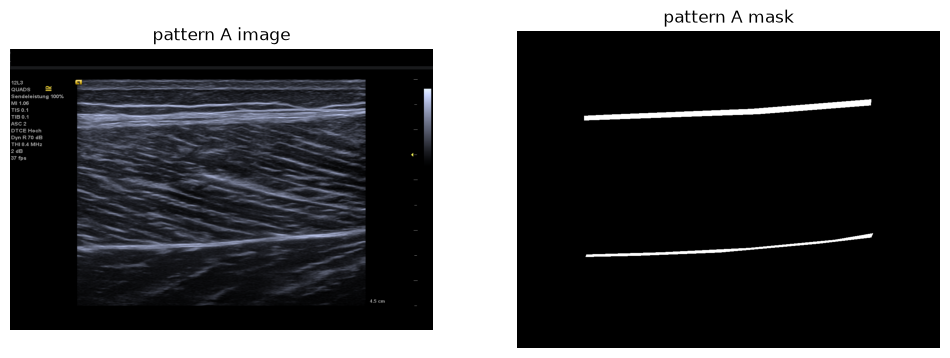

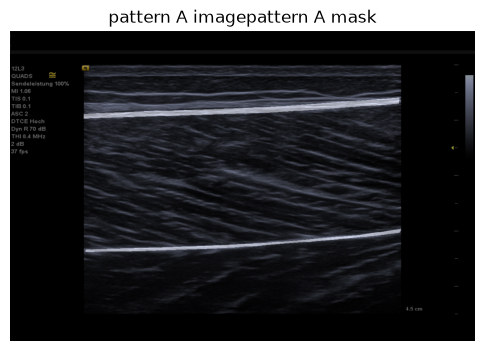

In [5]:
image_mask(
    os.path.join(apo_images_new_model_v1, pattern_a_file),
    os.path.join(apo_masks_new_model_v1, pattern_a_file),
    "pattern A image", "pattern A mask"
)

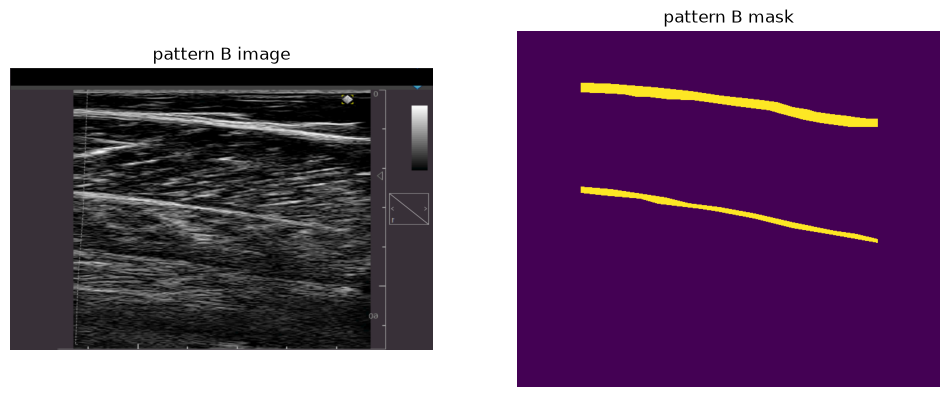

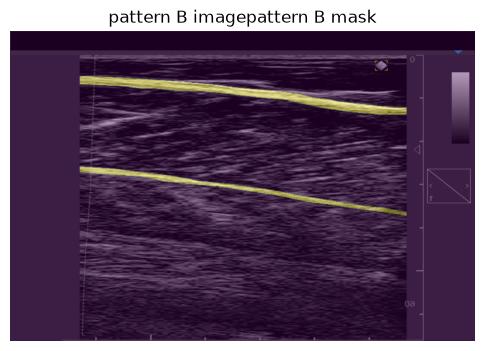

In [6]:
image_mask(
    os.path.join(apo_images_new_model_v1, pattern_b_file),
    os.path.join(apo_masks_new_model_v1, pattern_b_file),
    "pattern B image",
    "pattern B mask"
)

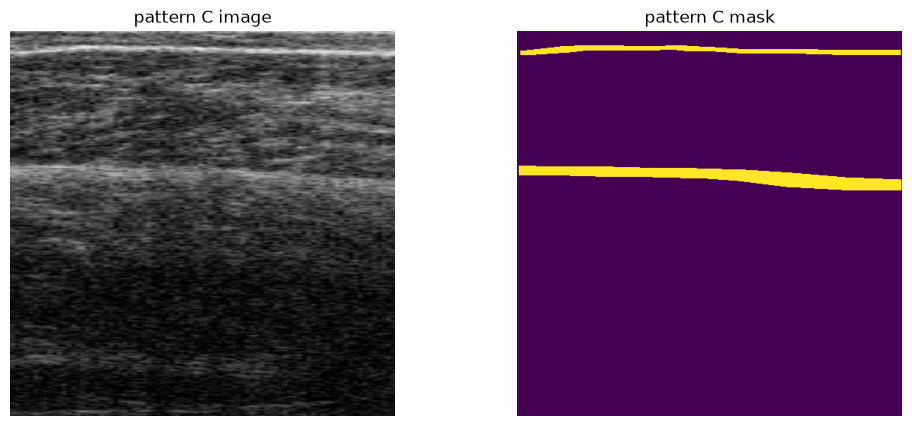

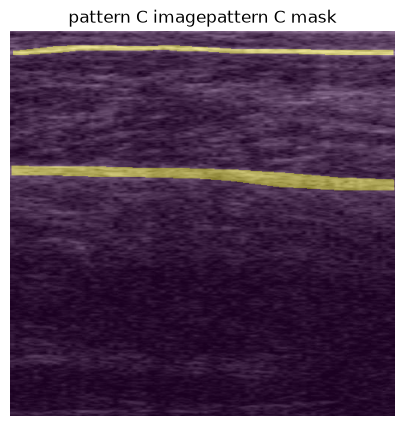

In [7]:
image_mask(
    os.path.join(apo_images_new_model_v1, pattern_c_file),
    os.path.join(apo_masks_new_model_v1, pattern_c_file),
    "pattern C image",
    "pattern C mask"
)

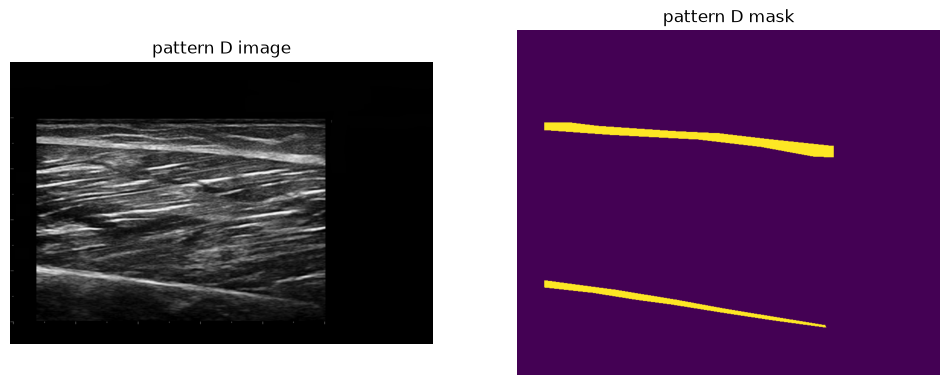

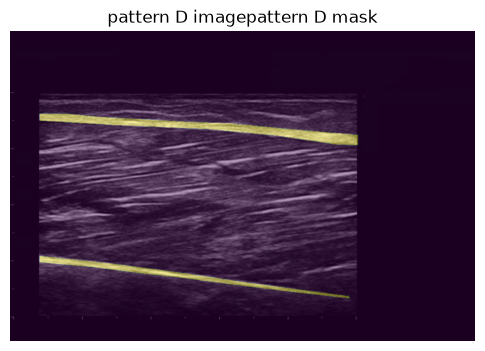

In [8]:
image_mask(
    os.path.join(apo_images_new_model_v1, pattern_d_file),
    os.path.join(apo_masks_new_model_v1, pattern_d_file),
    "pattern D image",
    "pattern D mask"
)

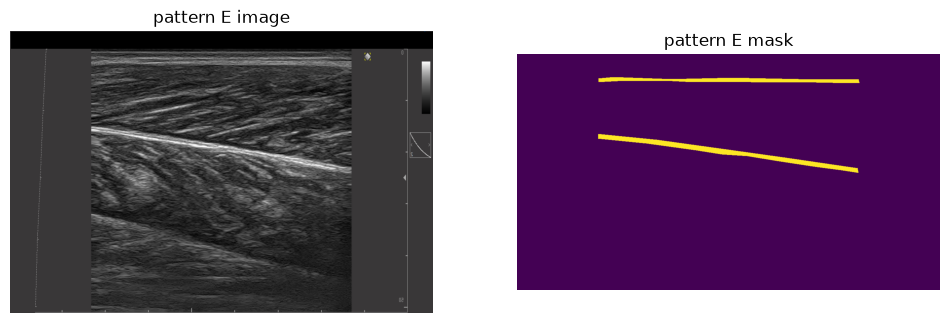

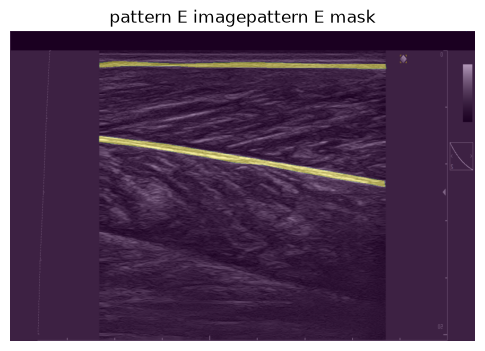

In [9]:
image_mask(
    os.path.join(apo_images_new_model_v1, pattern_e_file),
    os.path.join(apo_masks_new_model_v1, pattern_e_file),
    "pattern E image",
    "pattern E mask"
)

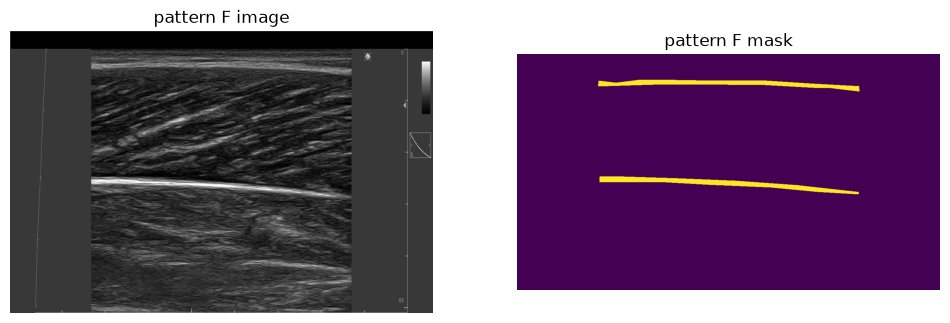

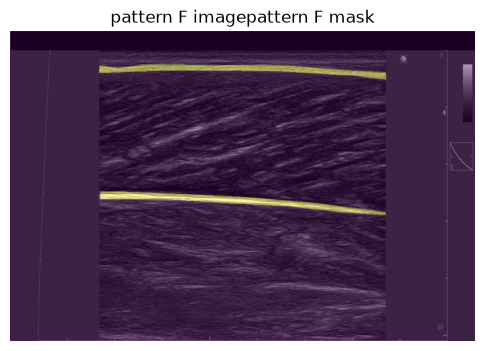

In [10]:
image_mask(
    os.path.join(apo_images_new_model_v1, pattern_f_file),
    os.path.join(apo_masks_new_model_v1, pattern_f_file),
    "pattern F image",
    "pattern F mask"
)

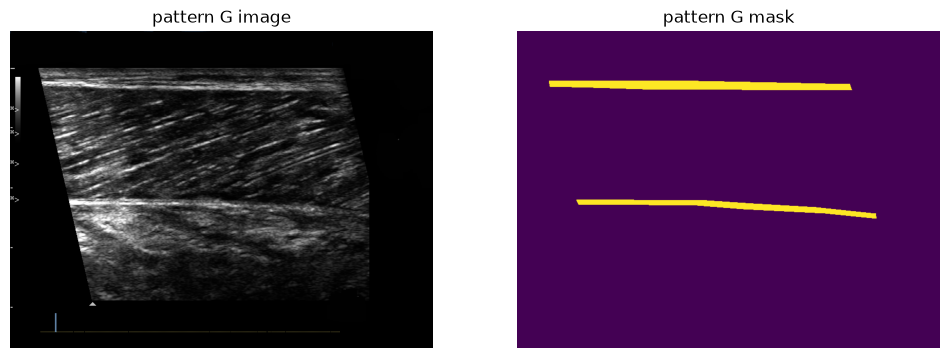

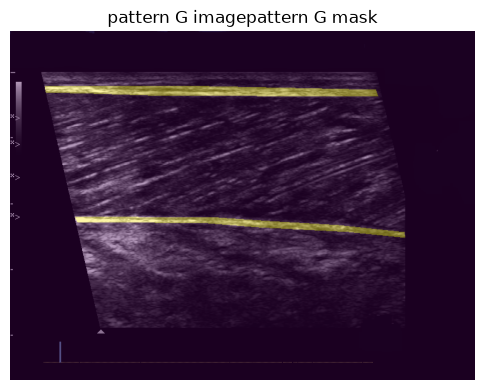

In [11]:
image_mask(
    os.path.join(apo_images_new_model_v1, pattern_g_file),
    os.path.join(apo_masks_new_model_v1, pattern_g_file),
    "pattern G image",
    "pattern G mask"
)

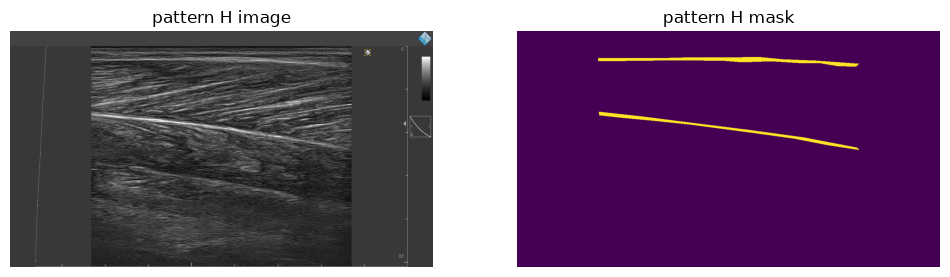

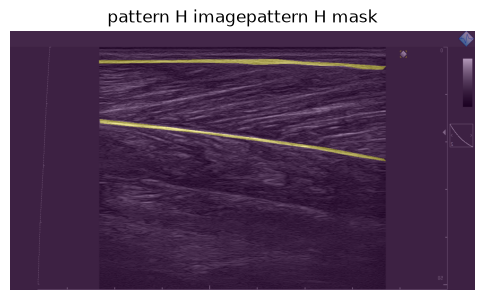

In [12]:
image_mask(
    os.path.join(apo_images_new_model_v1, pattern_h_file),
    os.path.join(apo_masks_new_model_v1, pattern_h_file),
    "pattern H image",
    "pattern H mask"
)

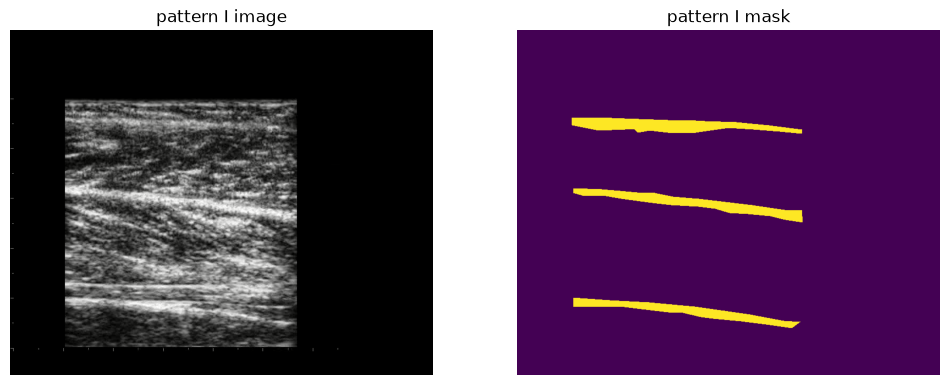

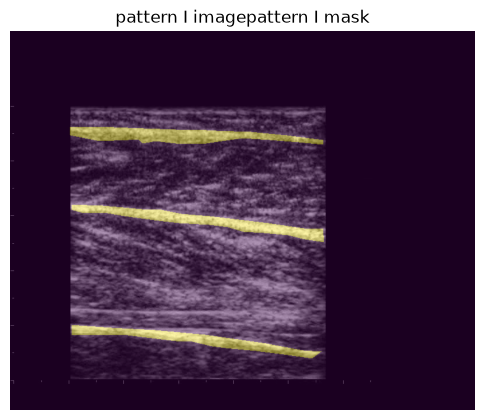

In [13]:
image_mask(
    os.path.join(apo_images_new_model_v1, pattern_i_file),
    os.path.join(apo_masks_new_model_v1, pattern_i_file),
    "pattern I image",
    "pattern I mask"
)

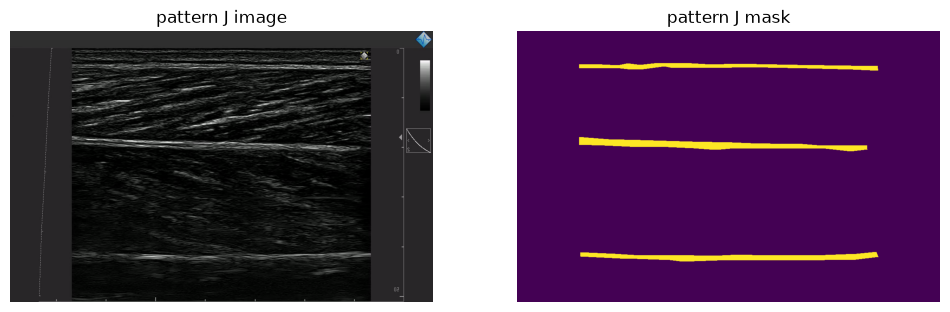

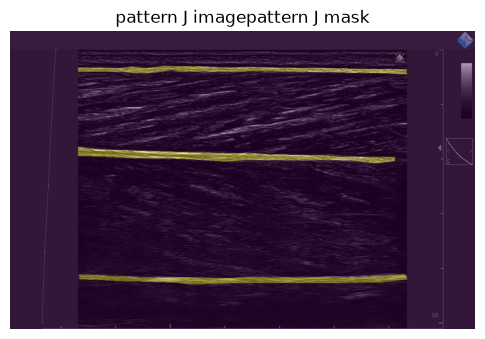

In [14]:
image_mask(
    os.path.join(apo_images_new_model_v1, pattern_j_file),
    os.path.join(apo_masks_new_model_v1, pattern_j_file),
    "pattern J image",
    "pattern J mask"
)

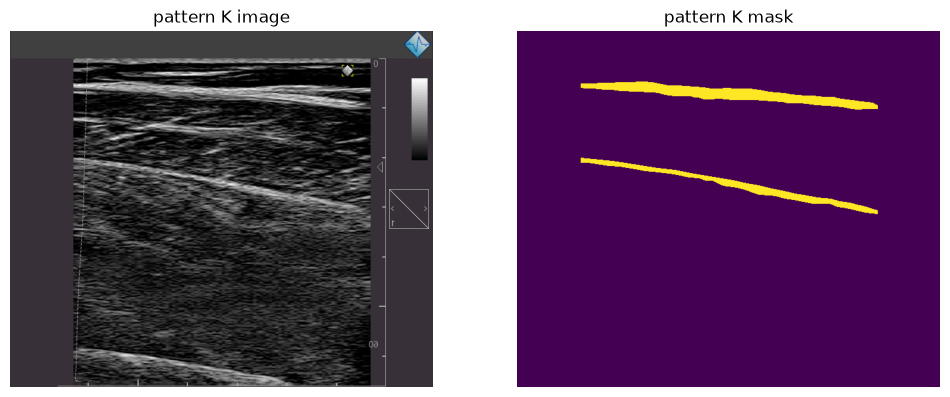

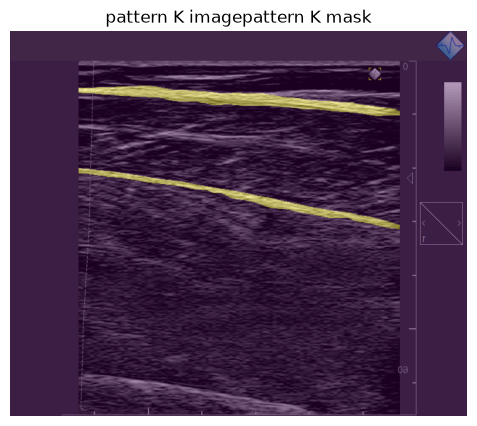

In [15]:
image_mask(
    os.path.join(apo_images_new_model_v1, pattern_k_file),
    os.path.join(apo_masks_new_model_v1, pattern_k_file),
    "pattern K image",
    "pattern K mask"
)

## fasc A〜P

In [16]:
check_image_mask_sizes(
    fasc_images_new_model_v1,
    fasc_masks_new_model_v1
)

files: 2761
image / mask size patterns:
image: (1200, 800) mask: (996, 556) count: 741
image: (1640, 1080) mask: (1640, 1080) count: 645
image: (1200, 800) mask: (660, 556) count: 169
image: (760, 500) mask: (760, 500) count: 216
image: (1200, 800) mask: (1152, 864) count: 426
image: (512, 512) mask: (512, 512) count: 79
image: (800, 652) mask: (800, 652) count: 42
image: (800, 600) mask: (800, 600) count: 65
image: (1200, 800) mask: (800, 652) count: 1
image: (1200, 800) mask: (800, 600) count: 13
image: (1200, 800) mask: (1234, 688) count: 15
image: (1200, 800) mask: (1234, 687) count: 1
image: (1200, 800) mask: (1074, 688) count: 5
image: (1200, 800) mask: (1196, 768) count: 101
image: (1200, 800) mask: (1088, 644) count: 121
image: (1200, 800) mask: (1340, 810) count: 121


* 全部でサイズの組み合わせが16パターンあることを確認

----

* Confirm that there are 16 size combinations in total.


In [17]:
pattern_a_file = find_image_by_size_pattern(
    fasc_images_new_model_v1,
    fasc_masks_new_model_v1,
    (1200, 800),
    (996, 556)
)

pattern_b_file = find_image_by_size_pattern(
    fasc_images_new_model_v1,
    fasc_masks_new_model_v1,
    (1640, 1080),
    (1640, 1080)
)

pattern_c_file = find_image_by_size_pattern(
    fasc_images_new_model_v1,
    fasc_masks_new_model_v1,
    (1200, 800),
    (660, 556)
)

pattern_d_file = find_image_by_size_pattern(
    fasc_images_new_model_v1,
    fasc_masks_new_model_v1,
    (760, 500),
    (760, 500)
)

pattern_e_file = find_image_by_size_pattern(
    fasc_images_new_model_v1,
    fasc_masks_new_model_v1,
    (1200, 800),
    (1152, 864)
)

pattern_f_file = find_image_by_size_pattern(
    fasc_images_new_model_v1,
    fasc_masks_new_model_v1,
    (512, 512),
    (512, 512)
)

pattern_g_file = find_image_by_size_pattern(
    fasc_images_new_model_v1,
    fasc_masks_new_model_v1,
    (800, 652),
    (800, 652)
)

pattern_h_file = find_image_by_size_pattern(
    fasc_images_new_model_v1,
    fasc_masks_new_model_v1,
    (800, 600),
    (800, 600)
)

pattern_i_file = find_image_by_size_pattern(
    fasc_images_new_model_v1,
    fasc_masks_new_model_v1,
    (1200, 800),
    (800, 652)
)

pattern_j_file = find_image_by_size_pattern(
    fasc_images_new_model_v1,
    fasc_masks_new_model_v1,
    (1200, 800),
    (800, 600)
)

pattern_k_file = find_image_by_size_pattern(
    fasc_images_new_model_v1,
    fasc_masks_new_model_v1,
    (1200, 800),
    (1234, 688)
)

pattern_l_file = find_image_by_size_pattern(
    fasc_images_new_model_v1,
    fasc_masks_new_model_v1,
    (1200, 800),
    (1234, 687)
)

pattern_m_file = find_image_by_size_pattern(
    fasc_images_new_model_v1,
    fasc_masks_new_model_v1,
    (1200, 800),
    (1074, 688)
)

pattern_n_file = find_image_by_size_pattern(
    fasc_images_new_model_v1,
    fasc_masks_new_model_v1,
    (1200, 800),
    (1196, 768)
)

pattern_o_file = find_image_by_size_pattern(
    fasc_images_new_model_v1,
    fasc_masks_new_model_v1,
    (1200, 800),
    (1088, 644)
)

pattern_p_file = find_image_by_size_pattern(
    fasc_images_new_model_v1,
    fasc_masks_new_model_v1,
    (1200, 800),
    (1340, 810)
)

print("pattern A:", pattern_a_file)
print("pattern B:", pattern_b_file)
print("pattern C:", pattern_c_file)
print("pattern D:", pattern_d_file)
print("pattern E:", pattern_e_file)
print("pattern F:", pattern_f_file)
print("pattern G:", pattern_g_file)
print("pattern H:", pattern_h_file)
print("pattern I:", pattern_i_file)
print("pattern J:", pattern_j_file)
print("pattern K:", pattern_k_file)
print("pattern L:", pattern_l_file)
print("pattern M:", pattern_m_file)
print("pattern N:", pattern_n_file)
print("pattern O:", pattern_o_file)
print("pattern P:", pattern_p_file)

pattern A: image_0000.tif
pattern B: image_0371.tif
pattern C: image_0671.tif
pattern D: image_0752.tif
pattern E: image_1558.tif
pattern F: image_2109.tif
pattern G: image_2110.tif
pattern H: image_2184.tif
pattern I: image_2295.tif
pattern J: image_2296.tif
pattern K: image_2297.tif
pattern L: image_2312.tif
pattern M: image_2325.tif
pattern N: image_2418.tif
pattern O: image_2519.tif
pattern P: image_2640.tif


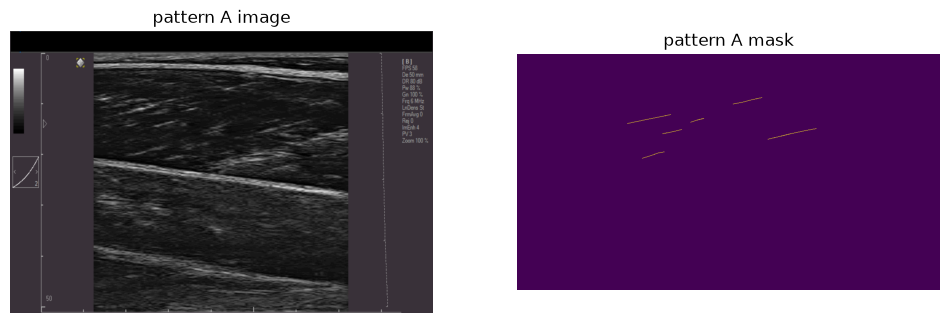

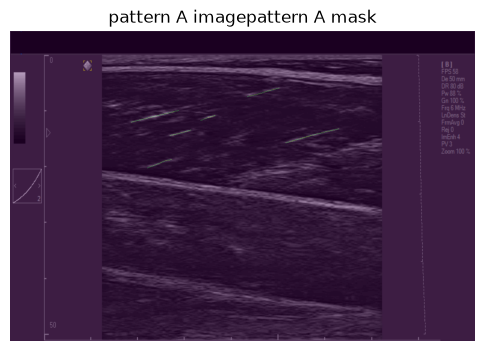

In [18]:
image_mask(
    os.path.join(fasc_images_new_model_v1, pattern_a_file),
    os.path.join(fasc_masks_new_model_v1, pattern_a_file),
    "pattern A image",
    "pattern A mask"
)


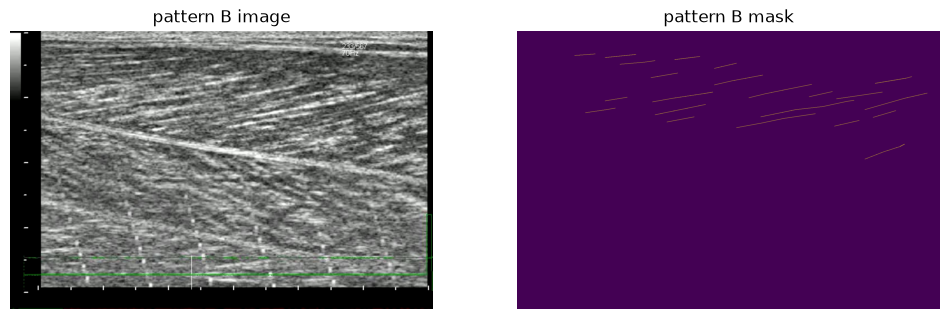

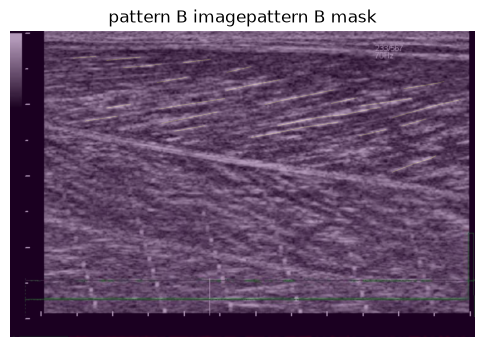

In [19]:
image_mask(
    os.path.join(fasc_images_new_model_v1, pattern_b_file),
    os.path.join(fasc_masks_new_model_v1, pattern_b_file),
    "pattern B image",
    "pattern B mask"
)

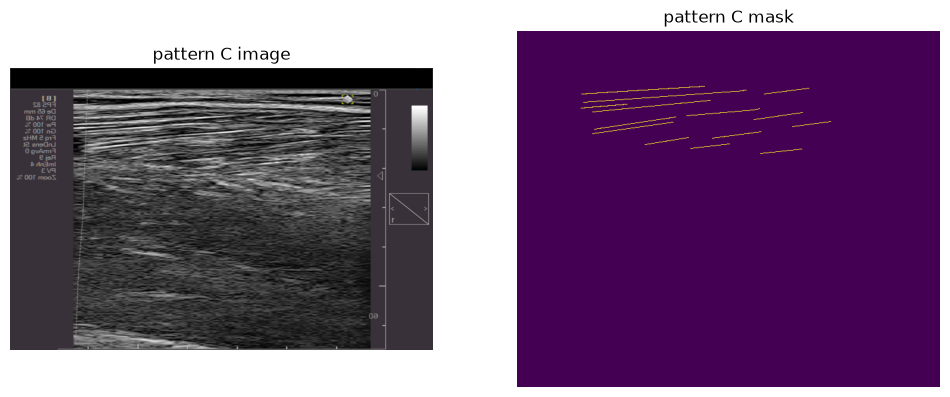

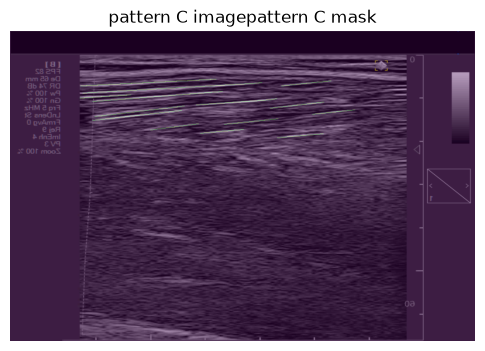

In [20]:
image_mask(
    os.path.join(fasc_images_new_model_v1, pattern_c_file),
    os.path.join(fasc_masks_new_model_v1, pattern_c_file),
    "pattern C image",
    "pattern C mask"
)

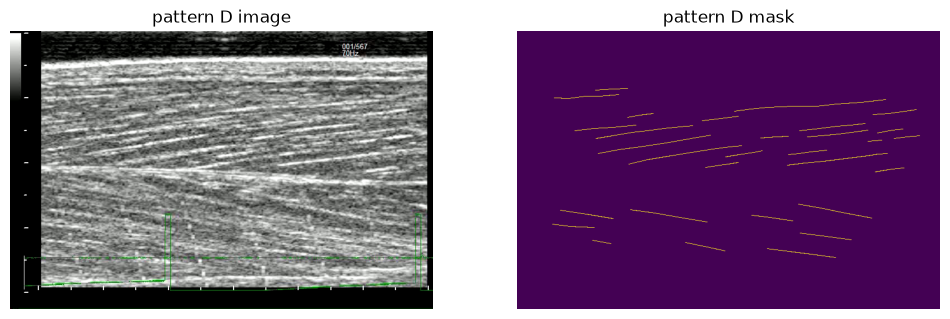

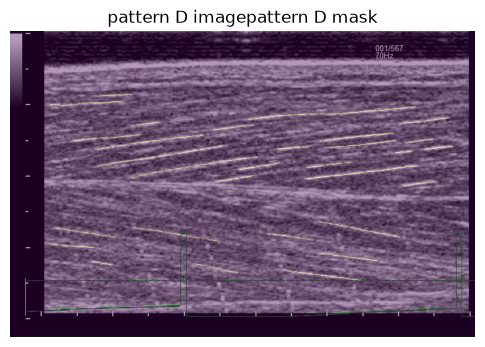

In [21]:
image_mask(
    os.path.join(fasc_images_new_model_v1, pattern_d_file),
    os.path.join(fasc_masks_new_model_v1, pattern_d_file),
    "pattern D image",
    "pattern D mask"
)

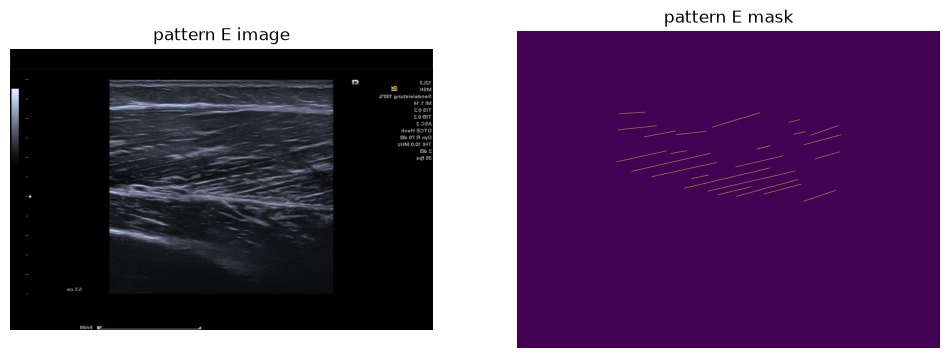

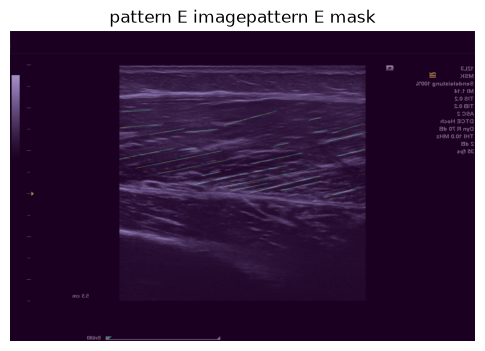

In [22]:
image_mask(
    os.path.join(fasc_images_new_model_v1, pattern_e_file),
    os.path.join(fasc_masks_new_model_v1, pattern_e_file),
    "pattern E image",
    "pattern E mask"
)

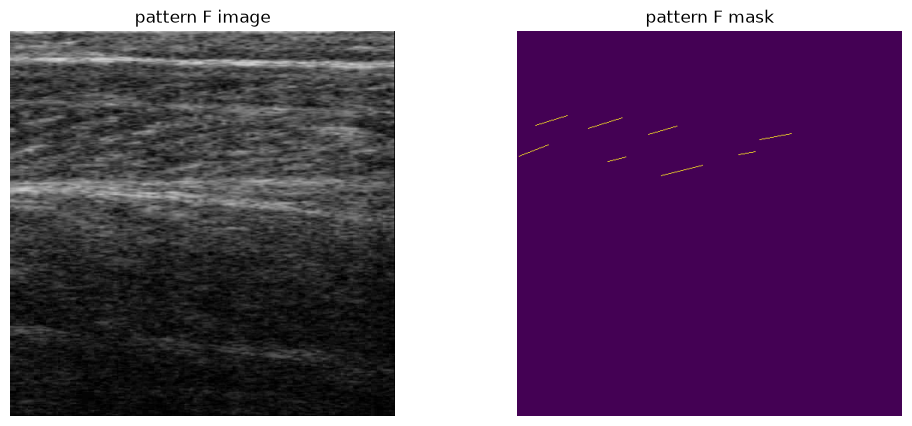

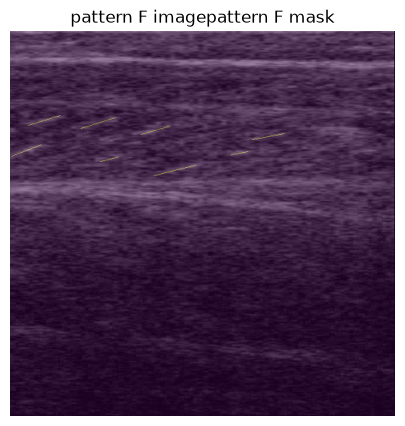

In [23]:
image_mask(
    os.path.join(fasc_images_new_model_v1, pattern_f_file),
    os.path.join(fasc_masks_new_model_v1, pattern_f_file),
    "pattern F image",
    "pattern F mask"
)

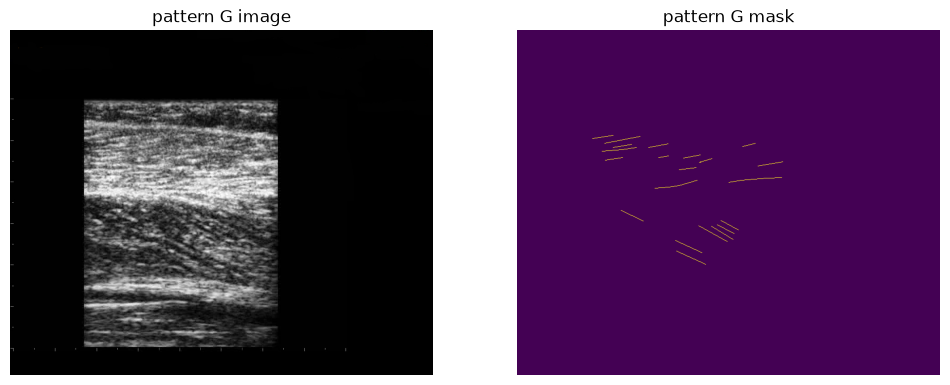

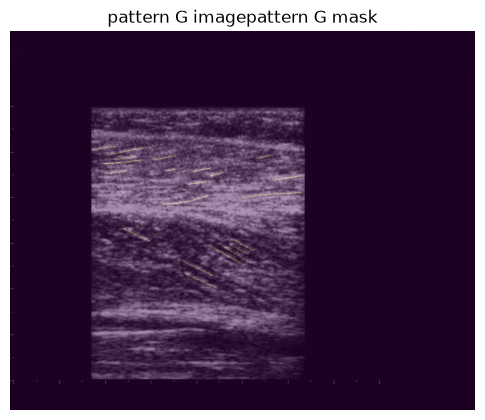

In [24]:
image_mask(
    os.path.join(fasc_images_new_model_v1, pattern_g_file),
    os.path.join(fasc_masks_new_model_v1, pattern_g_file),
    "pattern G image",
    "pattern G mask"
)

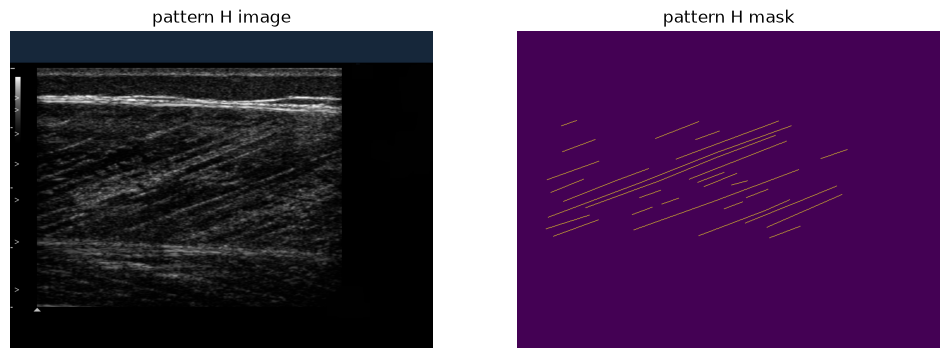

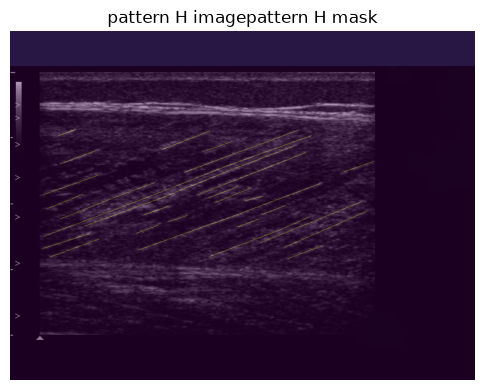

In [25]:
image_mask(
    os.path.join(fasc_images_new_model_v1, pattern_h_file),
    os.path.join(fasc_masks_new_model_v1, pattern_h_file),
    "pattern H image",
    "pattern H mask"
)

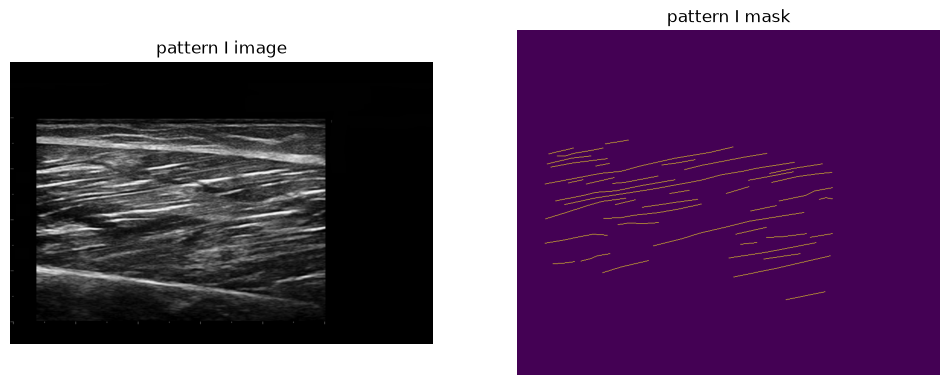

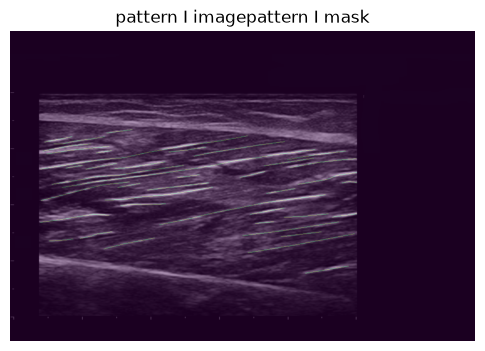

In [26]:
image_mask(
    os.path.join(fasc_images_new_model_v1, pattern_i_file),
    os.path.join(fasc_masks_new_model_v1, pattern_i_file),
    "pattern I image",
    "pattern I mask"
)

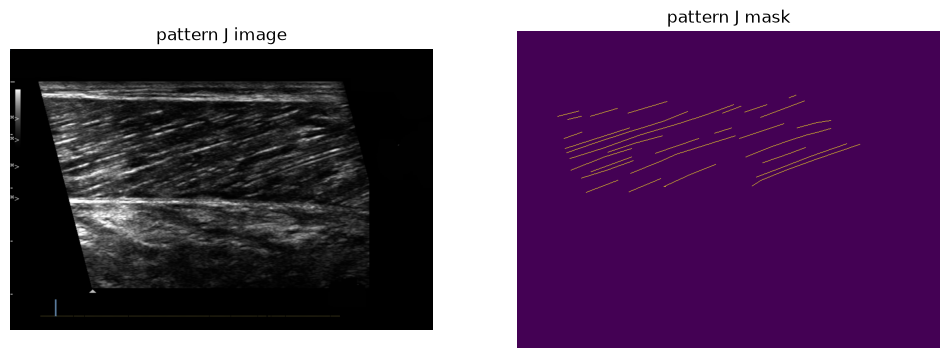

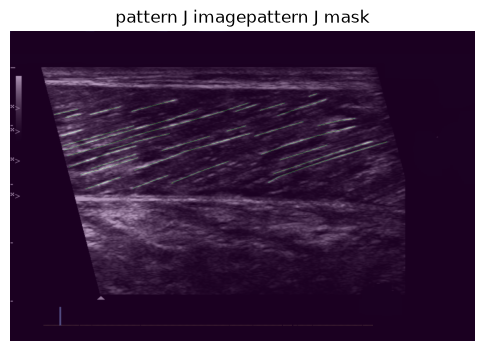

In [27]:
image_mask(
    os.path.join(fasc_images_new_model_v1, pattern_j_file),
    os.path.join(fasc_masks_new_model_v1, pattern_j_file),
    "pattern J image",
    "pattern J mask"
)

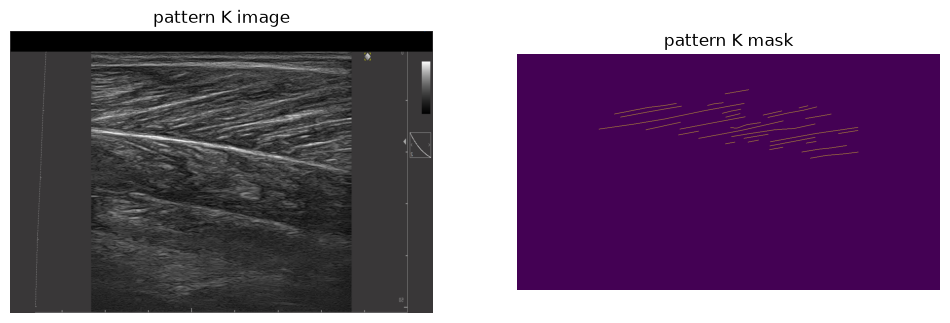

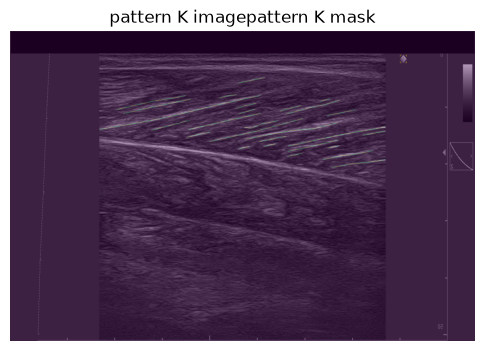

In [28]:
image_mask(
    os.path.join(fasc_images_new_model_v1, pattern_k_file),
    os.path.join(fasc_masks_new_model_v1, pattern_k_file),
    "pattern K image",
    "pattern K mask"
)

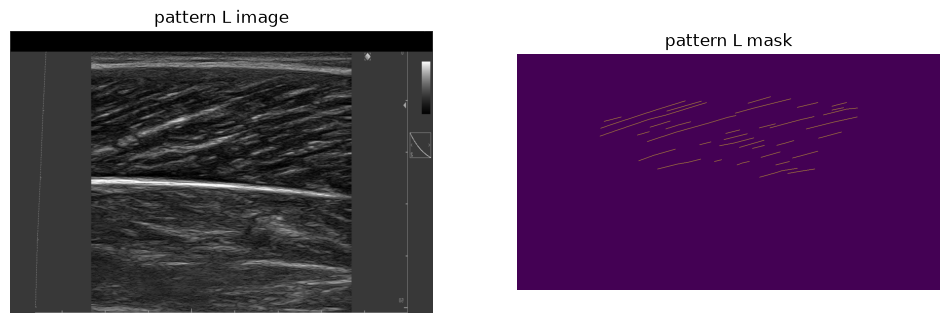

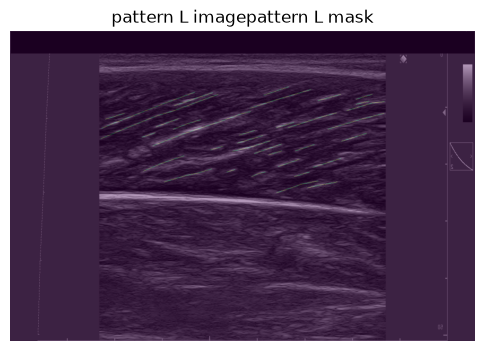

In [29]:
image_mask(
    os.path.join(fasc_images_new_model_v1, pattern_l_file),
    os.path.join(fasc_masks_new_model_v1, pattern_l_file),
    "pattern L image",
    "pattern L mask"
)


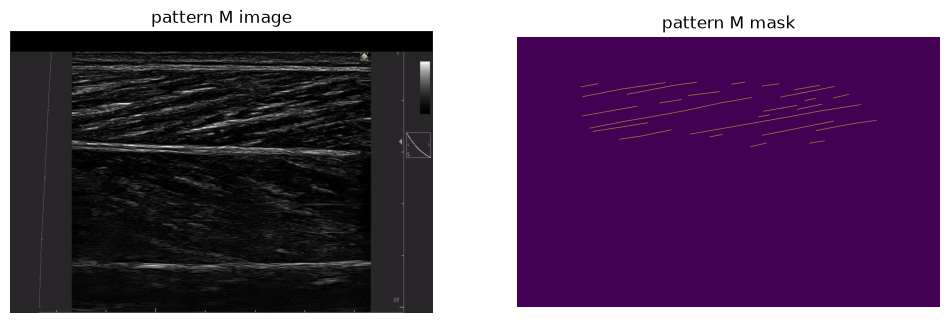

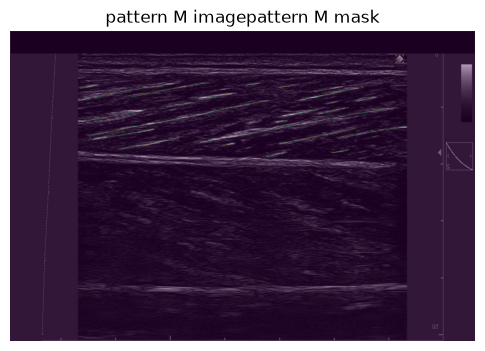

In [30]:
image_mask(
    os.path.join(fasc_images_new_model_v1, pattern_m_file),
    os.path.join(fasc_masks_new_model_v1, pattern_m_file),
    "pattern M image",
    "pattern M mask"
)


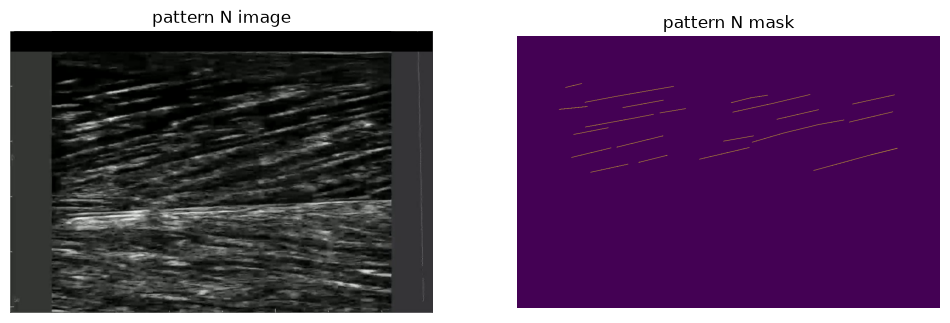

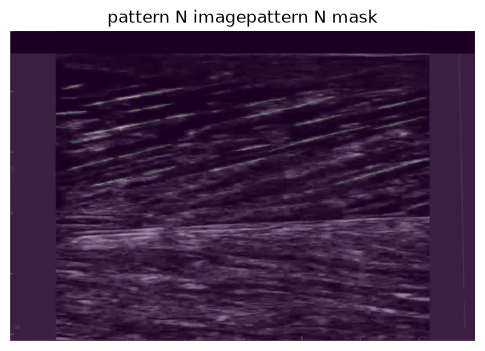

In [31]:
image_mask(
    os.path.join(fasc_images_new_model_v1, pattern_n_file),
    os.path.join(fasc_masks_new_model_v1, pattern_n_file),
    "pattern N image",
    "pattern N mask"
)

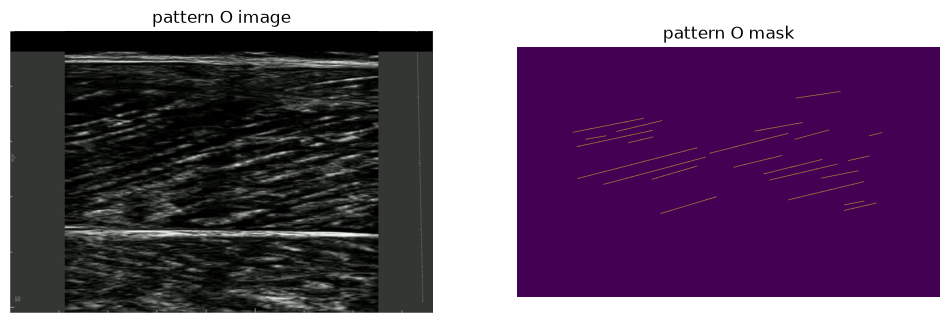

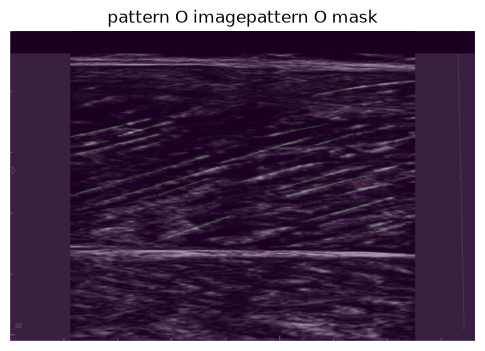

In [32]:
image_mask(
    os.path.join(fasc_images_new_model_v1, pattern_o_file),
    os.path.join(fasc_masks_new_model_v1, pattern_o_file),
    "pattern O image",
    "pattern O mask"
)

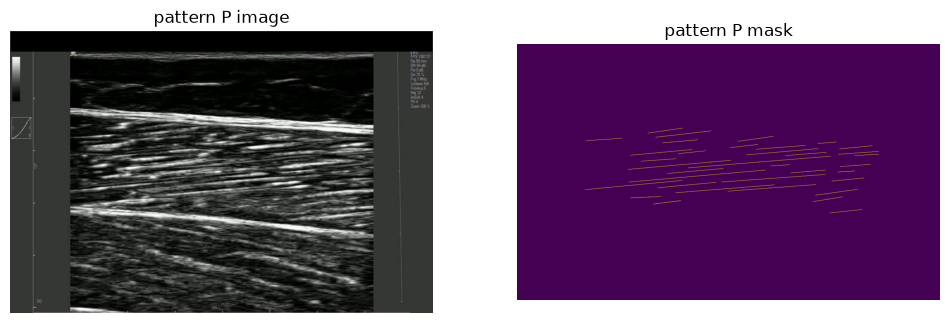

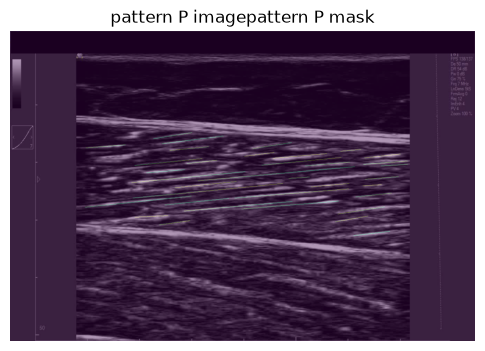

In [33]:
image_mask(
    os.path.join(fasc_images_new_model_v1, pattern_p_file),
    os.path.join(fasc_masks_new_model_v1, pattern_p_file),
    "pattern P image",
    "pattern P mask"
)

# result(結果)

* このnotebookで確認できたのは、
元画像とmaskのサイズが異なるケースでも、maskをimage.sizeに合わせてresizeすると、対応する構造位置に正しく重なる事
一応、すべての組み合わせのパターンを確認した。

----

* What I was able to confirm with this notebook is that even if the size of the original image and the mask are different, if you resize the mask to match the image.size, it will overlap correctly at the corresponding structure position.I have confirmed the patterns of all combinations.


```
image and mask have different sizes(image と mask のサイズが違う)
↓
fit mask to image.size(mask を image.size に合わせる)
↓
matching position(位置が一致する)
```
